# Logistic Regression 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

In [117]:
df = pd.read_csv("D:/FCDS/Syllabus/Spring 24-25/Machine Learning/MeINml/Car_prices.csv")

In [119]:
df.head()


,Unnamed: 0,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,max_power (in bph),Mileage Unit,Mileage,Engine (CC)
0,0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,5,74.00,kmpl,23.40,1248
1,2,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,5,90.00,kmpl,23.00,1396
2,4,Hyundai,2017,440000,45000,Petrol,Individual,Manual,First Owner,5,81.86,kmpl,20.14,1197
3,7,Toyota,2011,350000,90000,Diesel,Individual,Manual,First Owner,5,67.10,kmpl,23.59,1364
4,8,Ford,2013,200000,169000,Diesel,Individual,Manual,First Owner,5,68.10,kmpl,20.00,1399


In [121]:
print ('''
age: The age of the patient.
sex: Gender of the patient (0: female, 1: male).
cp: Type of chest pain.
trestbps: Resting blood pressure.
chol: Serum cholesterol.
fbs: Fasting blood sugar > 120 mg/dl.
restecg: Resting electrocardiographic results.
thalach: Maximum heart rate achieved.
exang: Exercise induced angina.
oldpeak: ST depression induced by exercise relative to rest
   ''')



age: The age of the patient.
sex: Gender of the patient (0: female, 1: male).
cp: Type of chest pain.
trestbps: Resting blood pressure.
chol: Serum cholesterol.
fbs: Fasting blood sugar > 120 mg/dl.
restecg: Resting electrocardiographic results.
thalach: Maximum heart rate achieved.
exang: Exercise induced angina.
oldpeak: ST depression induced by exercise relative to rest
   


In [123]:
print("dirt :", df.duplicated().sum())
print("shape of the dataset :" ,df.shape)

dirt : 0
shape of the dataset : (2095, 14)


In [125]:
df  = df.drop_duplicates()


In [127]:
df.shape

(2095, 14)

In [129]:
df.isnull().sum()

Unnamed: 0            0
name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
seats                 0
max_power (in bph)    0
Mileage Unit          0
Mileage               0
Engine (CC)           0
dtype: int64

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2095 entries, 0 to 2094
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          2095 non-null   int64  
 1   name                2095 non-null   object 
 2   year                2095 non-null   int64  
 3   selling_price       2095 non-null   int64  
 4   km_driven           2095 non-null   int64  
 5   fuel                2095 non-null   object 
 6   seller_type         2095 non-null   object 
 7   transmission        2095 non-null   object 
 8   owner               2095 non-null   object 
 9   seats               2095 non-null   int64  
 10  max_power (in bph)  2095 non-null   float64
 11  Mileage Unit        2095 non-null   object 
 12  Mileage             2095 non-null   float64
 13  Engine (CC)         2095 non-null   int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 229.3+ KB


In [133]:
corr_matrix = df.corr()
corr_matrix
# cp & target



ValueError: could not convert string to float: 'Maruti'

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,
            vmax=1,
            vmin= -1,
            annot= True,
            cmap= 'coolwarm')
plt.xticks(rotation=45, ha='right')
    
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
print(corr_matrix.shape)  # Should be (14, 14) for your 14 variables
print(corr_matrix.columns.tolist())  # Check if column names match rows


# Split data into features and target

In [19]:
X =df.drop('target', axis =1)
y = df['target']

In [20]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


# Split Train & Test

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
203,68,1,2,180,274,1,0,150,1,1.6,1,0,3
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
177,64,1,2,140,335,0,1,158,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,41,1,0,110,172,0,0,158,0,0.0,2,0,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
271,61,1,3,134,234,0,1,145,0,2.6,1,2,2


In [24]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,55,1,0,132,353,0,1,132,1,1.2,1,1,3
229,64,1,2,125,309,0,1,131,1,1.8,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
247,66,1,1,160,246,0,1,120,1,0.0,1,3,1
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,51,1,0,140,298,0,1,122,1,4.2,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2


# Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler
# use z-score normalization x_scaled= (x-mean)/stdeviation
# considered as the best way to normalize gradient descent-based models
#Ensures all features contribute equally to weight updates.
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_train_scaled

array([[-1.350641  ,  0.73145871,  0.        , ...,  0.96543644,
        -0.68348955, -0.54576155],
       [ 1.48742624,  0.73145871,  0.9664929 , ..., -0.68470669,
        -0.68348955,  1.14050171],
       [ 1.37826981,  0.73145871, -0.9664929 , ..., -0.68470669,
         1.35010281,  1.14050171],
       ...,
       [ 1.59658267,  0.73145871,  1.9329858 , ..., -0.68470669,
         0.33330663, -0.54576155],
       [ 0.72333121,  0.73145871,  1.9329858 , ..., -0.68470669,
         1.35010281, -0.54576155],
       [ 0.94164408, -1.36713116,  0.        , ...,  0.96543644,
         1.35010281, -0.54576155]])

In [27]:
X_test_scaled =  scaler.transform(X_test)
X_test_scaled

array([[ 6.83926194e-02,  7.31458712e-01, -9.66492901e-01,
         4.61039162e-02,  2.03233372e+00, -3.91292790e-01,
         8.90027648e-01, -7.93530525e-01,  1.51702665e+00,
         1.83646509e-01, -6.84706692e-01,  3.33306631e-01,
         1.14050171e+00],
       [ 1.05080051e+00,  7.31458712e-01,  9.66492901e-01,
        -3.48704747e-01,  1.19390909e+00, -3.91292790e-01,
         8.90027648e-01, -8.38286167e-01,  1.51702665e+00,
         7.23388078e-01, -6.84706692e-01, -6.83489548e-01,
         1.14050171e+00],
       [ 2.86705484e-01,  7.31458712e-01,  9.66492901e-01,
         1.06132619e+00, -2.29317518e+00,  2.55563104e+00,
         8.90027648e-01,  1.04145078e+00, -6.59184200e-01,
        -7.15922773e-01,  9.65436435e-01,  3.33306631e-01,
         1.14050171e+00],
       [ 1.26911337e+00,  7.31458712e-01,  0.00000000e+00,
         1.62533857e+00, -6.56254664e-03, -3.91292790e-01,
         8.90027648e-01, -1.33059822e+00,  1.51702665e+00,
        -8.95836630e-01, -6.84706692e

# Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state =0).fit(X_train_scaled, y_train) 

In [85]:
log_reg.predict(X_train_scaled)


array([1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1],
      dtype=int64)

In [87]:
log_reg.score(X_train_scaled, y_train)

0.8589211618257261

In [50]:
log_reg.score(X_test_scaled, y_test)

0.8360655737704918

In [52]:
# let's play with parameters to observe accuracy
log_reg1 = LogisticRegression(random_state =0,
                             C =.1,
                             fit_intercept =True).fit(X_train_scaled, y_train) 

In [54]:
log_reg1.score(X_train_scaled, y_train)

0.8672199170124482

In [56]:
log_reg1.score(X_test_scaled, y_test)

0.8524590163934426

In [58]:
log_reg1.coef_


array([[-0.05374244, -0.5366985 ,  0.49472311, -0.28838348, -0.09756793,
         0.08980101,  0.19065132,  0.37555929, -0.4050494 , -0.41512072,
         0.35135038, -0.55622281, -0.48571707]])

In [60]:
log_reg1.intercept_


array([0.18909161])

# Model Evaluation

We use confusion Matrix to evaluate the performance of the model

In [64]:
log_reg1.predict_proba(X_train_scaled)


array([[0.1273427 , 0.8726573 ],
       [0.8653151 , 0.1346849 ],
       [0.7366134 , 0.2633866 ],
       [0.20812166, 0.79187834],
       [0.14101998, 0.85898002],
       [0.20340869, 0.79659131],
       [0.23025702, 0.76974298],
       [0.25537168, 0.74462832],
       [0.93204373, 0.06795627],
       [0.04668869, 0.95331131],
       [0.17969315, 0.82030685],
       [0.5841317 , 0.4158683 ],
       [0.17376332, 0.82623668],
       [0.97493075, 0.02506925],
       [0.16390701, 0.83609299],
       [0.37516799, 0.62483201],
       [0.26996431, 0.73003569],
       [0.97727465, 0.02272535],
       [0.90239274, 0.09760726],
       [0.98685503, 0.01314497],
       [0.62051345, 0.37948655],
       [0.25228153, 0.74771847],
       [0.35840201, 0.64159799],
       [0.28422189, 0.71577811],
       [0.86543006, 0.13456994],
       [0.97487972, 0.02512028],
       [0.16253502, 0.83746498],
       [0.22998221, 0.77001779],
       [0.58476492, 0.41523508],
       [0.14411318, 0.85588682],
       [0.

In [66]:
log_reg1.predict_proba(X_test_scaled)


array([[0.93883087, 0.06116913],
       [0.78703391, 0.21296609],
       [0.24392364, 0.75607636],
       [0.86062515, 0.13937485],
       [0.08471805, 0.91528195],
       [0.15879997, 0.84120003],
       [0.40969956, 0.59030044],
       [0.94550887, 0.05449113],
       [0.97231913, 0.02768087],
       [0.53659786, 0.46340214],
       [0.25364057, 0.74635943],
       [0.90946724, 0.09053276],
       [0.12969923, 0.87030077],
       [0.83380946, 0.16619054],
       [0.02637135, 0.97362865],
       [0.10705787, 0.89294213],
       [0.02843431, 0.97156569],
       [0.98513047, 0.01486953],
       [0.97637534, 0.02362466],
       [0.95562465, 0.04437535],
       [0.50855   , 0.49145   ],
       [0.96508497, 0.03491503],
       [0.74556262, 0.25443738],
       [0.28156267, 0.71843733],
       [0.10224097, 0.89775903],
       [0.36079066, 0.63920934],
       [0.97188096, 0.02811904],
       [0.42682075, 0.57317925],
       [0.95513823, 0.04486177],
       [0.08661958, 0.91338042],
       [0.

Confusion Matrix

In [103]:
from sklearn.metrics import confusion_matrix # for true pos, neg & false pos, neg
y_pred = log_reg1.predict(X_test_scaled)


confusion_matrix(y_test, y_pred) # The confusion matrix is computed by comparing:

#y_test: The true labels from your test dataset

#y_pred: The predicted labels generated by your model

array([[25,  4],
       [ 5, 27]], dtype=int64)

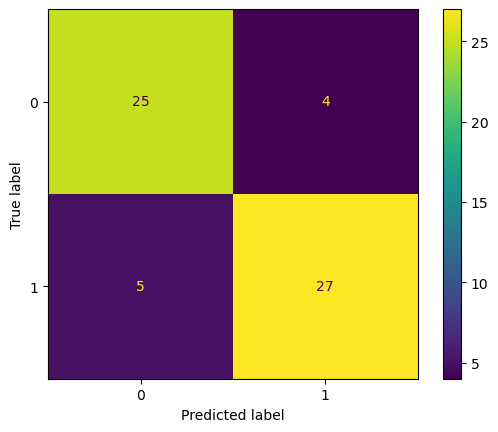

In [105]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot()
plt.show()

In [107]:
y_train

132    1
203    0
197    0
75     1
177    0
      ..
189    0
71     1
106    1
271    0
102    1
Name: target, Length: 241, dtype: int64

In [109]:
y_pred.sum()

31

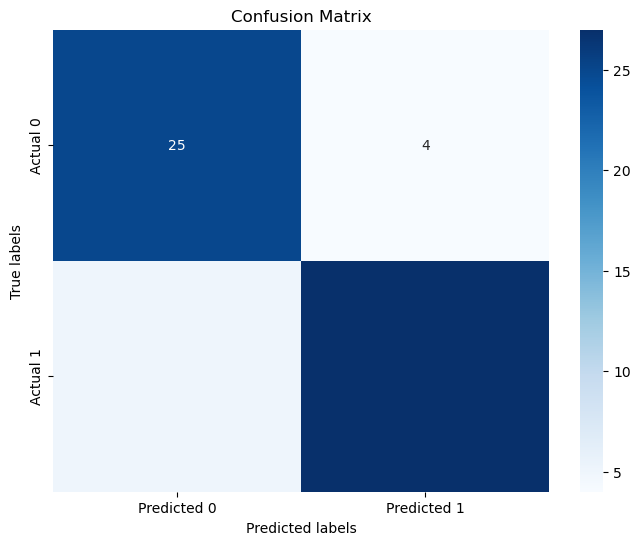

In [111]:

cm = confusion_matrix(y_test, y_pred)
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [113]:
from sklearn import metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
Precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
F1_score = metrics.f1_score(y_test, y_pred)


print(f"accuracy :{accuracy} ")
print(f"Precision :{Precision} ")
print(f"recall :{recall} ")
print(f"F1_score :{F1_score} ")

accuracy :0.8524590163934426 
Precision :0.8709677419354839 
recall :0.84375 
F1_score :0.8571428571428571 


In [115]:
y_test.count()

61